# Quantum Amplitude Estimation
Dado un operador $\mathcal{A}$ que actúa como:
$$ \mathcal{A} = \sqrt{1 - a}\ket{\Psi_0} + \sqrt{a}\ket{\Psi_1}$$
el Quantum Amplitude Estimation (QAE) es el método de encontrar una estimación para la amplitud a del estado $\ket{\Psi_1}$:
$$ a = |\bra{\Psi_1}\ket{\Psi_1}|^2$$
Este método fue por primera vez investigado por Brassard et al. en el año 200 y su algoritmo utiliza una combinación del operador de Grover
$$\mathcal{Q} = \mathcal{A}\mathcal{S}_0\mathcal{A}^\dagger\mathcal{S}_{\Psi_1} $$
donde $\mathcal{S}_0$ y $\mathcal{S}_{\Psi_1}$ son refexiones de los estados $\ket{0}$ y $\ket{\psi_1}$ respectivamente y estimaciones de fase. De todas formas, este algoritmo llamado AmplitudeEstimation en Qiskit Algorithms, requiere circuitos largos y es caro a nivel computacional. Además, otras variantes del QAE han sido propuestas, por lo que en este tutorial se mostrará un ejemplo sencillo.

En este ejemplo, $\mathcal{A}$ describe una variable aleatoria de Bernoulli con una probabilidad de suceso *p*:
$$\mathcal{A}|0\rangle = \sqrt{1 - p}|0\rangle + \sqrt{p}|1\rangle.$$
En un ordenador cuántico, podemos modelizar este operador como una rotacion entorno al eje **Y** de un qbit.
$$ \mathcal{A} = R_Y(\theta_p), \theta_p = 2\sin^{-1}(\sqrt{p}). $$
Para este caso, el operador de Grover es particularmente simple:
$$\mathcal{Q} = R_Y(2\theta_p),$$
cuyas potencias son muy fáciles de calcular: $\mathcal{Q}^k = R_Y(2k\theta_p)$

Fijaremos la probabilidad que queremos estimar como **$p = 0.2$**.

In [2]:
p = 0.2

Ahora podemos definir los circuitos para $\mathcal{A}$ y $\mathcal{Q}$.

In [9]:
import numpy as np
from qiskit.circuit import QuantumCircuit

class BernoulliA(QuantumCircuit):
    """Circuito que representa el operador de Bernoulli A"""
    
    def __init__(self, probability):
        super().__init__(1) #Circuito de un qbit

        theta_p = 2 * np.arcsin(np.sqrt(probability))
        self.ry(theta_p, 0)

class BernoulliQ(QuantumCircuit):
    """Circuito que representa el operador de Bernoulli B"""

    def __init__(self, probability):
        super().__init__(1)

        self.theta_p = 2 * np.arcsin(np.sqrt(probability))
        self.ry(2 * self.theta_p, 0)

    def power(self, k):
        #Implementa las potencias de Q
        q_k = QuantumCircuit(1)
        q_k.ry(2 * k *self.theta_p, 0)
        return q_k

In [10]:
A = BernoulliA(p)
Q = BernoulliQ(p)

## Proceso del Amplitude Estimation
Los algoritmos de Qiskit implementan diferentes algortimos QAE derivados de la interfaz AmplitudeEstimator. En el inicializador especificamos la configuración del algoritmo y el método de estimación, que hacen todos el trabajo, toma un input de EstimationProblem y devuelve un objeto AmplitudeEstimationResult. Como todas las variaciones del QAE siguen la misma interfaz, podemos usar todas a la vez para resolver un mismo problema.

A continuación, corremos los diferentes algoritmos QAE. Para ello, comenzamos definiendo el problema de estimación que contiene los operadores $\mathcal{A}$ y $\mathcal{Q}$ y cómo se identifica el estado $\ket{\Psi_1}$, que en este ejemplo sera $\ket{1}$.

In [21]:
from qiskit_algorithms import EstimationProblem

problem = EstimationProblem (
    state_preparation = A, #Operador A
    grover_operator = Q, #Operador Q
    objective_qubits = [0] #El estado Psi1 se identifica midiendo |1> en el qubit 0
)

Para ejecutar los circuitos utilizamos Sampler.

In [28]:
from qiskit.primitives import StatevectorSampler as Sampler

sampler = Sampler()

# AE canónico
Resolvamos con el QAE original implementado por Brassard et al.

In [29]:
from qiskit_algorithms import AmplitudeEstimation

ae = AmplitudeEstimation (
    num_eval_qubits = 3, #El número de evaluación de qubits especifica de anchura y precisión al circuito
    sampler = sampler,
)

Con el algoritmo definido, podemos llamar a `estimate` y darle el problema a resolver.

In [30]:
ae_result = ae.estimate(problem)

La estimación está disponible en `estimation`:

In [31]:
print(ae_result.estimation)

0.1464466


Observamos que no es una muy buena estimación para nuestro objetivo $p = 0.2$. Esto se debe al hecho de que el AE canónico está restringido a una red discreta, especificada por el número de qubits de evaluación:

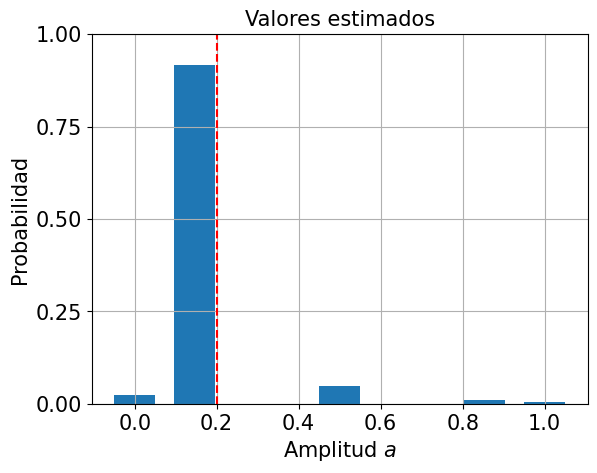

In [33]:
import matplotlib.pyplot as plt

#Graficar los distintos valores
gridpoints = list(ae_result.samples.keys())
probabilities = list(ae_result.samples.values())

plt.bar(gridpoints, probabilities, width = 0.5 / len(probabilities))
plt.axvline(p, color="r", ls= "--")
plt.xticks(size = 15)
plt.yticks([0, 0.25, 0.5, 0.75, 1], size = 15)
plt.title("Valores estimados", size = 15)
plt.ylabel("Probabilidad", size = 15)
plt.xlabel(r"Amplitud $a$", size = 15)
plt.ylim((0,1))
plt.grid()
plt.show()

Para mejorar la estimación podemos interpolar las probabilidades medidas y computar el estimador con mayor capacidad para producir esta distribución de probabilidad:

In [34]:
print("Estimador MLE interpolado:", ae_result.mle)

Estimador MLE interpolado: 0.1969647871694174


Podemos echar un vistazo al circuito que ejecuta el AE:

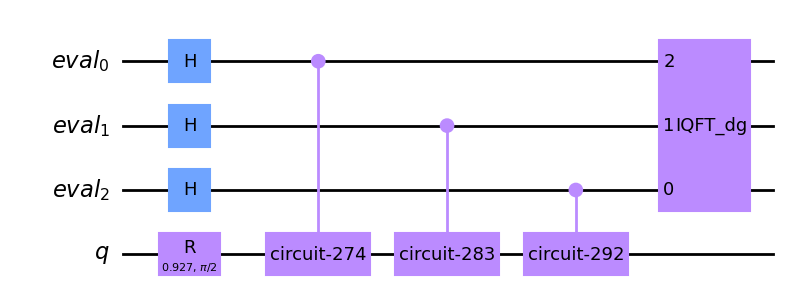

In [35]:
ae_circuit = ae.construct_circuit(problem)
ae_circuit.decompose().draw(
    "mpl", style = "clifford"
) #Descompone 1 nivel: muestra el circuito de estimación de fase.

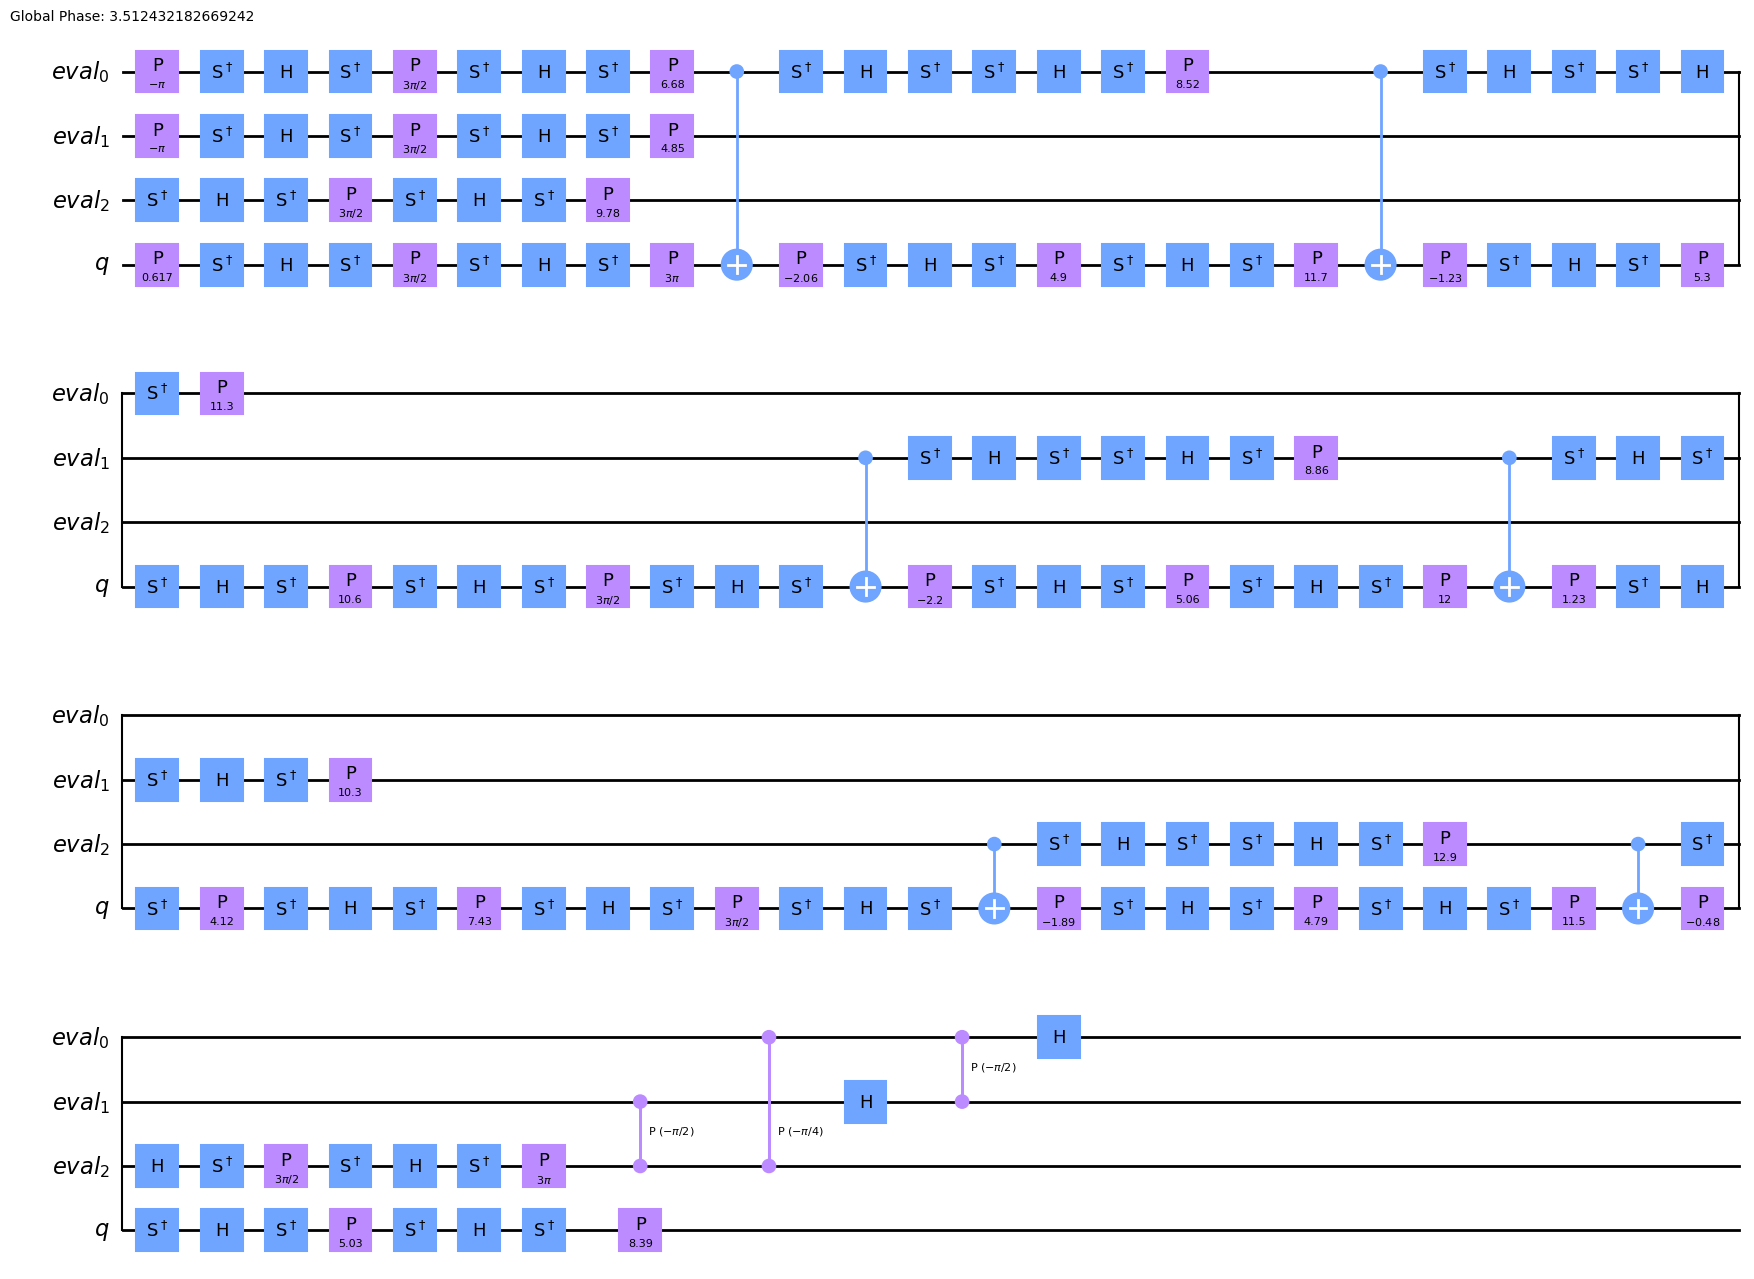

In [36]:
from qiskit import transpile

basis_gates = ["h", "ry", "cry", "cx", "ccx", "p", "cp", "x", "s", "sdg", "y", "t", "cz"]
transpile(ae_circuit, basis_gates=basis_gates, optimization_level=2).draw("mpl", style="clifford")

# Iterative Amplitude Estimation

In [38]:
from qiskit_algorithms import IterativeAmplitudeEstimation

iae = IterativeAmplitudeEstimation(
    epsilon_target = 0.01, #Precisión buscada.
    alpha = 0.05, # Anchura del intervalo de confianza
         sampler = sampler,
)
iae_result = iae.estimate(problem)

print("Estimación:", iae_result.estimation)

Estimación: 0.19806500112789513


Aquí, los circuitos solo consisten en potencias de Grover y resulta mucho menos costoso

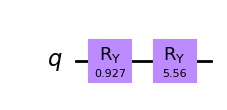

In [39]:
iae_circuit = iae.construct_circuit(problem, k = 3)
iae_circuit.draw("mpl", style = "clifford")

# Maximum Likelihood Amplitude Estimation

In [40]:
from qiskit_algorithms import MaximumLikelihoodAmplitudeEstimation

mlae = MaximumLikelihoodAmplitudeEstimation(
    evaluation_schedule = 3,
    sampler = sampler,
)
mlae_result = mlae.estimate(problem)

print("Estimación:", mlae_result.estimation)

Estimación: 0.20136059320297045


# Faster Amplitude Estimation

In [42]:
from qiskit_algorithms import FasterAmplitudeEstimation

fae = FasterAmplitudeEstimation(
    delta = 0.01, #Precisión buscada.
    maxiter = 3, #Máxima potencia de Grover utilizada
    sampler= sampler,  
)
fae_result = fae.estimate(problem)

print("Estimación:", fae_result.estimation)

Estimación: 0.1989850728307093


C:\Users\riosb\miniconda3\Lib\site-packages\qiskit_algorithms\amplitude_estimators\estimation_problem.py:215: UserWarning: Rescaling discards the Grover operator.
  warnings.warn("Rescaling discards the Grover operator.")
